In [20]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# Task 1.1
M = np.array(Image.open("anh.jpg").convert("L"), dtype=float)

height, width = M.shape
print("Shape của M: ", M.shape)

h = height // 3
w = width // 3

sub_image = []
for i in range(3):
    for j in range(3):
        sub_matrix = M[i*h : (i+1)*h, j*w : (j+1)*w]
        sub_image.append(sub_matrix.flatten())

X = np.array(sub_image)
print("Shape của X: ", X.shape)

# Task 1.2
X_mean = np.mean(X, axis=0)
X_center = X - X_mean
print("Shape của X trước khi trừ: ", X.shape)
print("Shape của vector trung bình theo cột: ", X_mean.shape)
print("Shape của X sau khi trừ: ", X_center.shape)

# Task 1.3
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

S = cosine_similarity(X)
print("Shape của ma trận tương đồng S: ", S.shape)

# Task 1.4
def search(query, top_k=3):
    query_2d = query.reshape(1, -1)
    score = cosine_similarity(X, query_2d).flatten()
    top_index = np.argsort(score)[::-1][:top_k]
    return top_index, score[top_index]

# Chạy thử
print("CHẠY THỬ ẢNH")
top_index, top_score = search(X[0], top_k=9)
for idx, score in zip(top_index, top_score):
    print(f"Sub-image {idx}: cosine similarity = {score:.4f}")



Shape của M:  (958, 1266)
Shape của X:  (9, 134618)
Shape của X trước khi trừ:  (9, 134618)
Shape của vector trung bình theo cột:  (134618,)
Shape của X sau khi trừ:  (9, 134618)
Shape của ma trận tương đồng S:  (9, 9)
CHẠY THỬ ẢNH
Sub-image 0: cosine similarity = 1.0000
Sub-image 1: cosine similarity = 0.9264
Sub-image 2: cosine similarity = 0.9107
Sub-image 5: cosine similarity = 0.8382
Sub-image 4: cosine similarity = 0.7889
Sub-image 7: cosine similarity = 0.7885
Sub-image 3: cosine similarity = 0.7344
Sub-image 8: cosine similarity = 0.7299
Sub-image 6: cosine similarity = 0.7081


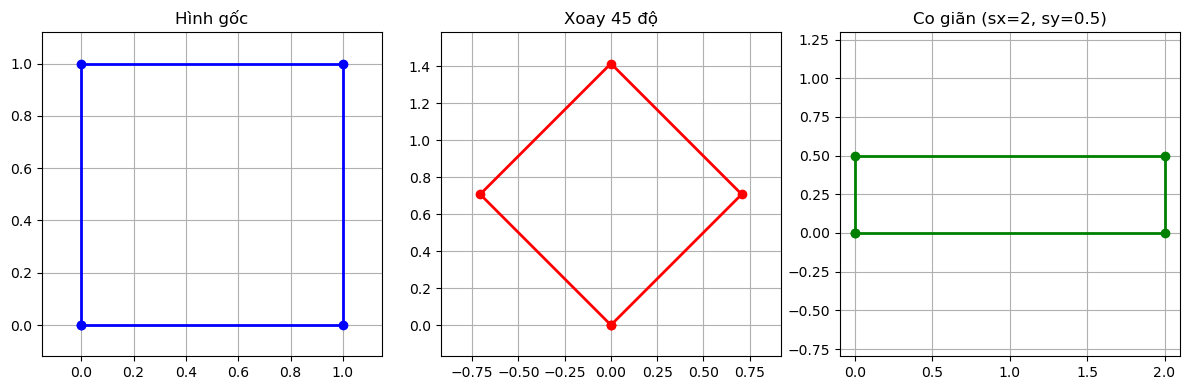

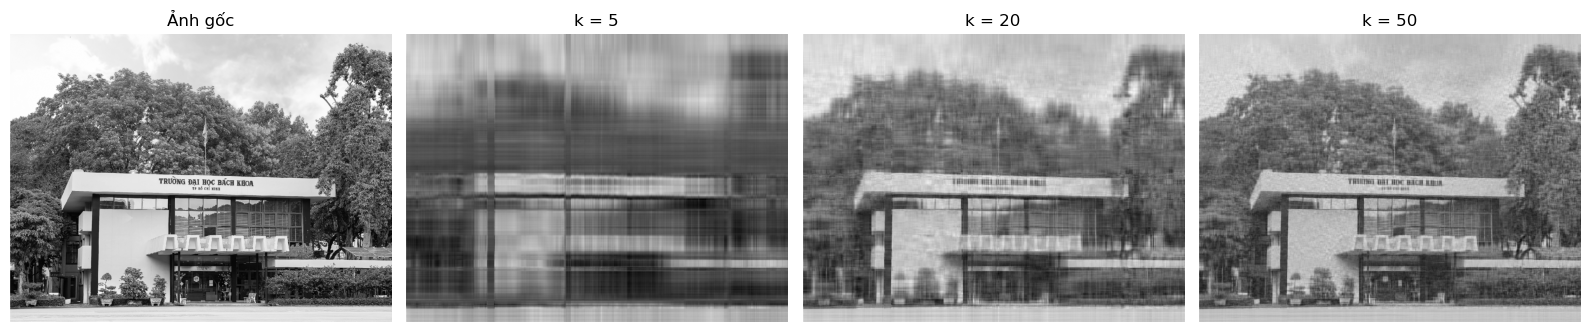

k =  5 | Sai số: 46138 | Tỉ lệ nén: 0.92%
k = 20 | Sai số: 36268 | Tỉ lệ nén: 3.67%
k = 50 | Sai số: 30857 | Tỉ lệ nén: 9.17%


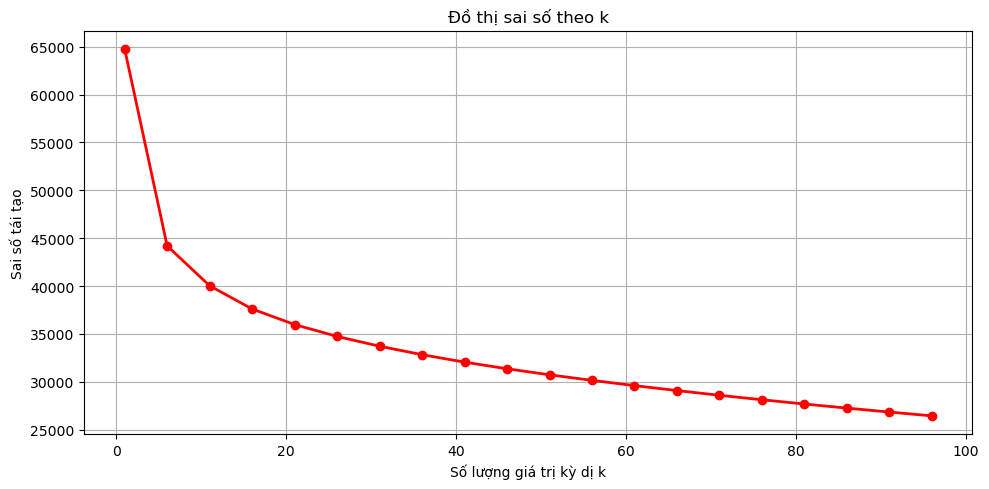

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Task 2.1
def rotation_matrix(degrees):
    theta = np.radians(degrees)
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0],
        [0, sy]
    ])

# Tạo hình vuông cạnh là 1
points = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0]
])

# Xoay 45 độ
R = create_rotation_matrix(45)
points_rotated = R @ points

# Giãn chiều ngang 2 lần, co chiều dọc lại 1/2
S = create_scaling_matrix(2, 0.5)
points_scaled = S @ points

# Vẽ bằng Matplotlib
plt.figure(figsize=(12, 4))

# Hình gốc
plt.subplot(1, 3, 1)
plt.plot(points[0], points[1], marker='o', color='blue', linewidth=2)
plt.title("Hình gốc")
plt.grid(True)
plt.axis('equal')

# Hình sau khi xoay
plt.subplot(1, 3, 2)
plt.plot(points_rotated[0], points_rotated[1], marker='o', color='red', linewidth=2)
plt.title("Xoay 45 độ")
plt.grid(True)
plt.axis('equal')

# Hình sau khi co giãn
plt.subplot(1, 3, 3)
plt.plot(points_scaled[0], points_scaled[1], marker='o', color='green', linewidth=2)
plt.title("Co giãn (sx=2, sy=0.5)")
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()

# Task 2.2
U, S, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

k_values = [5, 20, 50]
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(M, cmap='gray')
plt.title("Ảnh gốc")
plt.axis('off')

for i, k in enumerate(k_values, start=2):
    M_reconstructed = reconstruct(k)
    plt.subplot(1, 4, i)
    plt.imshow(M_reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Task 2.3
m, n = M.shape
original_size = m * n

k_list = list(range(1, 101, 5))
errors = []
compression_ratio = []

# Tính toán sai số và tỉ lệ nén cho từng k
for k in k_list:
    M_rec = reconstruct(k)
    
    # Tính sai số
    error = np.linalg.norm(M - M_rec, 'fro')
    errors.append(error)
    
    # U (m x k), S (k), Vt (k x n) => Tổng số phần tử = k * (m + n + 1)
    compressed_size = k * (m + n + 1)
    ratio = (compressed_size / original_size) * 100
    compression_ratio.append(ratio)

# So sánh các mốc k
for k_test in [5, 20, 50]:
    M_test = reconstruct(k_test)
    err = np.linalg.norm(M - M_test, 'fro')
    comp_size = k_test * (m + n + 1)
    ratio = (comp_size / original_size) * 100
    print(f"k = {k_test:2d} | Sai số: {err:.0f} | Tỉ lệ nén: {ratio:.2f}%")

# Vẽ đồ thị sai số theo k
plt.figure(figsize=(10, 5))
plt.plot(k_list, errors, marker='o', color='red', linestyle='-', linewidth=2)
plt.title("Đồ thị sai số theo k")
plt.xlabel("Số lượng giá trị kỳ dị k")
plt.ylabel("Sai số tái tạo")
plt.grid(True)
plt.tight_layout()
plt.show()

Nhận xét bài 2: Theo em, bắt đầu từ khoảng k = 50 thì ảnh vẫn chấp nhận được. Đối với k nhỏ, chẳng hạn như k = 5 thì ảnh bị nhiễu nặng và gần như không thể hình dung được các chi tiết trong ảnh, với k = 20 thì ảnh rõ nét hơn đôi chút, có bố cục nhưng nhìn chung vẫn chưa rõ ràng, khó nhìn. Trong AI, dữ liệu thường có rất nhiều chiều nên nếu sử dụng SVD để thu thập những điểm quan trọng và bỏ bớt những điểm kém quan trọng sẽ giúp giảm chi phí tính toán và tăng tốc độ tính toán, đồng thời việc nén dữ liệu giúp hệ thống phân tích các dữ liệu và hạn chế quá tải bộ nhớ.

Nhận xét bài 1: Cặp ảnh (0,1), (0,2) có độ giống nhau lớn (ta không xét cặp (0,0) vì bản thân so với chính nó thì cosine similarity = 1), theo trực giác với ảnh minh hoạ, 3 vị trí 0,1,2 này chính là 3 ô nằm ở hàng trên cùng của bước ảnh và nó chứa phần bầu trời, tán lá cây khá tương đồng với nhau. Trong khi đó, cặp ảnh (0,6) có sự khác biệt nhất, trong ảnh minh hoạ, ô 0 chứa bầu trời, tán lá còn ô 6 lại chứa chủ yếu là kiến trúc thư viện Bách Khoa (các vị trí gần ô 6 cũng tương tự nên có cosine similarity nhỏ). Vì vậy, nhìn chung kết quả khớp trực giác.

Trả lời câu hỏi 1.1: Ảnh ban đầu được chia ra thành 9 ảnh nhỏ (sub_image). Mỗi hàng trong ma trận X biểu diễn thông tin của 1 ảnh nhỏ đó vì đã được trải phẳng thành vector 1 chiều, do đó số hàng cũng chính là số mẫu dữ liệu (9 ảnh nhỏ - 9 mẫu). Trong khi đó, mỗi cột trong ma trận X biểu diễn đặc trưng hay độ sáng của 1 điểm ảnh trong mỗi ảnh nhỏ, nên số cột chính là tổng số điểm ảnh trong 1 ảnh nhỏ.
